<a href="https://colab.research.google.com/github/Hodaram/Hoda-ramadan-hassan/blob/main/CIFAR_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# %% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  CELL 1 — Install & Imports
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
!pip install datasets -q

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json, time, warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {len(tf.config.list_physical_devices('GPU')) > 0}")


TensorFlow : 2.20.0
GPU        : True


In [ ]:
# %% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  CELL 2 — Load CIFAR-10 من HuggingFace
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
from datasets import load_dataset

CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']
NUM_CLASSES  = 10

print("Downloading CIFAR-10 from HuggingFace …")
ds = load_dataset("cifar10")

X_train_raw = np.array([np.array(img) for img in ds['train']['img']])
y_train_raw = np.array(ds['train']['label'])
X_test_raw  = np.array([np.array(img) for img in ds['test']['img']])
y_test_raw  = np.array(ds['test']['label'])

print(f"✅ Train: {X_train_raw.shape}  |  Test: {X_test_raw.shape}")


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

✅ Train: (50000, 32, 32, 3)  |  Test: (10000, 32, 32, 3)


In [ ]:
# %% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  CELL 3 — Preprocessing: Resize 32×32 → 224×224
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TARGET_SIZE  = (224, 224)
SUBSET_TRAIN = 5000    # None = full 50k (needs high RAM)
SUBSET_TEST  = 1000    # None = full 10k

def resize_dataset(X, y, n_samples=None):
    if n_samples:
        idx = np.random.choice(len(X), n_samples, replace=False)
        X, y = X[idx], y[idx]
    X_resized = tf.image.resize(X, TARGET_SIZE).numpy()
    return preprocess_input(X_resized), y

print("Resizing train …")
X_train, y_train = resize_dataset(X_train_raw, y_train_raw, SUBSET_TRAIN)
print("Resizing test  …")
X_test,  y_test  = resize_dataset(X_test_raw,  y_test_raw,  SUBSET_TEST)
print(f"✅ Train: {X_train.shape}  |  Test: {X_test.shape}")

# Train / Val Split 80/20
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.20, stratify=y_train, random_state=42)

y_tr_oh  = to_categorical(y_tr,  NUM_CLASSES)
y_val_oh = to_categorical(y_val, NUM_CLASSES)
print(f"Train:{X_tr.shape[0]}  Val:{X_val.shape[0]}  Test:{X_test.shape[0]}")

# Augmentation
augmentor = ImageDataGenerator(
    rotation_range=15, width_shift_range=0.1, height_shift_range=0.1,
    horizontal_flip=True, zoom_range=0.1, fill_mode='nearest')


Resizing train …
Resizing test  …
✅ Train: (5000, 224, 224, 3)  |  Test: (1000, 224, 224, 3)
Train:4000  Val:1000  Test:1000



  APPROACH 1: VGG16 Feature Extraction + SVM
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Extracting features — train …
  45.3s  shape: (4000, 25088)
PCA components: 2961
Training SVM …

── Approach 1 Results ──────────────────────────
  Accuracy  : 80.50%
  Precision : 80.87%
  Recall    : 80.60%
  F1-Score  : 80.63%
  Time      : 18.0s


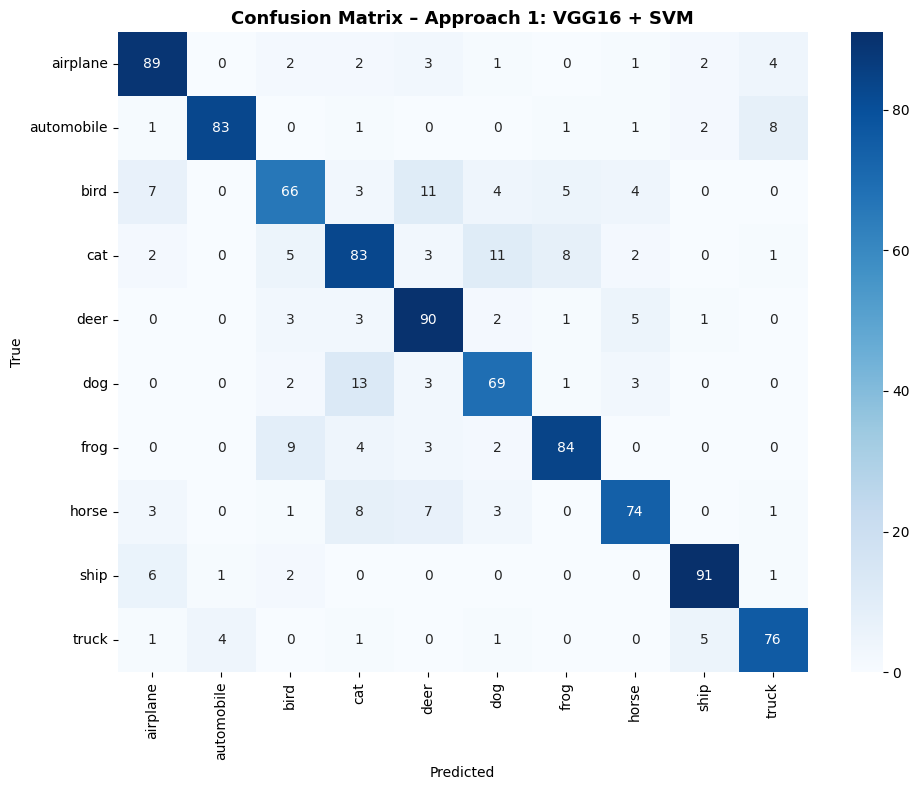

              precision    recall  f1-score   support

    airplane       0.82      0.86      0.84       104
  automobile       0.94      0.86      0.90        97
        bird       0.73      0.66      0.69       100
         cat       0.70      0.72      0.71       115
        deer       0.75      0.86      0.80       105
         dog       0.74      0.76      0.75        91
        frog       0.84      0.82      0.83       102
       horse       0.82      0.76      0.79        97
        ship       0.90      0.90      0.90       101
       truck       0.84      0.86      0.85        88

    accuracy                           0.81      1000
   macro avg       0.81      0.81      0.81      1000
weighted avg       0.81      0.81      0.80      1000



In [ ]:
# %% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  CELL 4 — APPROACH 1: VGG16 Feature Extraction + SVM
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("\n" + "="*55)
print("  APPROACH 1: VGG16 Feature Extraction + SVM")
print("="*55)

# Feature extractor (frozen VGG16)
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
vgg_base.trainable = False
feature_extractor = Model(inputs=vgg_base.input, outputs=vgg_base.output)

def extract_features(X, model, batch_size=32):
    features = []
    for i in range(0, len(X), batch_size):
        batch = X[i:i+batch_size]
        feat  = model.predict(batch, verbose=0)
        features.append(feat.reshape(feat.shape[0], -1))
    return np.vstack(features)

print("Extracting features — train …")
t0 = time.time()
X_tr_feat   = extract_features(X_tr,   feature_extractor)
print(f"  {time.time()-t0:.1f}s  shape: {X_tr_feat.shape}")
X_val_feat  = extract_features(X_val,  feature_extractor)
X_test_feat = extract_features(X_test, feature_extractor)

# Scale + PCA
scaler = StandardScaler()
X_tr_s   = scaler.fit_transform(X_tr_feat)
X_val_s  = scaler.transform(X_val_feat)
X_test_s = scaler.transform(X_test_feat)

pca = PCA(n_components=0.95, random_state=42)
X_tr_pca   = pca.fit_transform(X_tr_s)
X_val_pca  = pca.transform(X_val_s)
X_test_pca = pca.transform(X_test_s)
print(f"PCA components: {X_tr_pca.shape[1]}")

# Train SVM
SVM_KERNEL = 'linear'
SVM_C      = 1.0
svm_clf = SVC(kernel=SVM_KERNEL, C=SVM_C, random_state=42)
print(f"Training SVM …")
t0 = time.time()
svm_clf.fit(X_tr_pca, y_tr)
svm_train_time = time.time() - t0

# Evaluate
y_pred_svm = svm_clf.predict(X_test_pca)
acc_svm  = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm, average='macro')
rec_svm  = recall_score(y_test, y_pred_svm, average='macro')
f1_svm   = f1_score(y_test, y_pred_svm, average='macro')
cm_svm   = confusion_matrix(y_test, y_pred_svm)

print(f"\n── Approach 1 Results ──────────────────────────")
print(f"  Accuracy  : {acc_svm*100:.2f}%")
print(f"  Precision : {prec_svm*100:.2f}%")
print(f"  Recall    : {rec_svm*100:.2f}%")
print(f"  F1-Score  : {f1_svm*100:.2f}%")
print(f"  Time      : {svm_train_time:.1f}s")

# Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix – Approach 1: VGG16 + SVM', fontsize=13, fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.savefig('cm_approach1_svm.png', dpi=150, bbox_inches='tight')
plt.show()
print(classification_report(y_test, y_pred_svm, target_names=CLASS_NAMES))


GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Loading CIFAR-10 ...


Resizing...
Train: 1600 Val: 400

Building model...

Training (Frozen)...
Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 53s 417ms/step - accuracy: 0.1406 - loss: 4.4300 - val_accuracy: 0.3175 - val_loss: 2.0964
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 256ms/step - accuracy: 0.2081 - loss: 2.9178 - val_accuracy: 0.4175 - val_loss: 1.6879
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 239ms/step - accuracy: 0.2763 - loss: 2.2981 - val_accuracy: 0.4800 - val_loss: 1.5105
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 238ms/step - accuracy: 0.3419 - loss: 1.9521 - val_accuracy: 0.5200 - val_loss: 1.3842
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 233ms/step - accuracy: 0.3887 - loss: 1.8037 - val_accuracy: 0.5725 - val_loss: 1.2874
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 232ms/step - accuracy: 0.4200 - loss: 1.6751 - val_accuracy: 0.6075 - val_loss: 1.2024
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 238ms/step - accuracy: 0.4525 - loss: 1.6228 - val_accuracy: 0.6100 - val_loss: 1.1485
Epoch 8/1

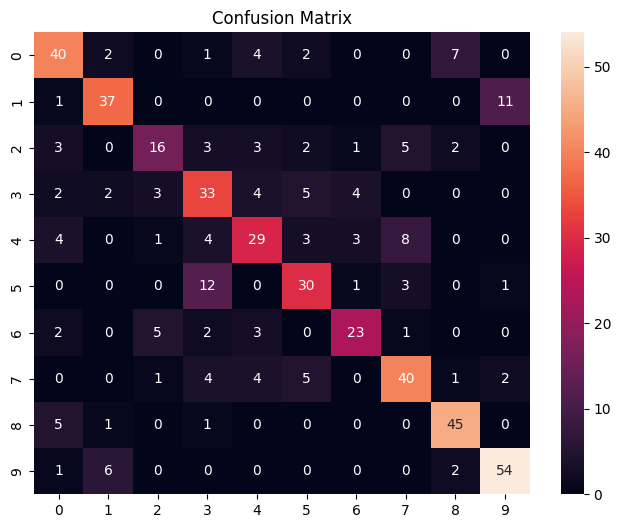


Classification Report:
              precision    recall  f1-score   support

    airplane       0.69      0.71      0.70        56
  automobile       0.77      0.76      0.76        49
        bird       0.62      0.46      0.52        35
         cat       0.55      0.62      0.58        53
        deer       0.62      0.56      0.59        52
         dog       0.64      0.64      0.64        47
        frog       0.72      0.64      0.68        36
       horse       0.70      0.70      0.70        57
        ship       0.79      0.87      0.83        52
       truck       0.79      0.86      0.82        63

    accuracy                           0.69       500
   macro avg       0.69      0.68      0.68       500
weighted avg       0.69      0.69      0.69       500



In [ ]:
# %% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  CELL 5 — VGG16 End-to-End (224 VERSION - STABLE)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

!pip install datasets -q

import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from datasets import load_dataset
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ── GPU Check ─────────────────────────────────────────────
print("GPU:", tf.config.list_physical_devices('GPU'))

# ── Settings ──────────────────────────────────────────────
CLASS_NAMES   = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

NUM_CLASSES   = 10
TARGET_SIZE   = (224, 224)   # ✔️ تم التعديل
SUBSET_TRAIN  = 2000         # ممكن تزود لو عندك GPU قوي
SUBSET_TEST   = 500
BATCH_SIZE    = 16           # ✔️ مهم علشان 224
EPOCHS        = 10
DROPOUT_RATE  = 0.5

# ── Load Data ─────────────────────────────────────────────
print("Loading CIFAR-10 ...")
ds = load_dataset("cifar10")

X_train_raw = np.array([np.array(img) for img in ds['train']['img']])
y_train_raw = np.array(ds['train']['label'])

X_test_raw  = np.array([np.array(img) for img in ds['test']['img']])
y_test_raw  = np.array(ds['test']['label'])

# ── Resize ────────────────────────────────────────────────
def resize_dataset(X, y, n_samples):
    idx = np.random.choice(len(X), n_samples, replace=False)
    X, y = X[idx], y[idx]
    X = tf.image.resize(X, TARGET_SIZE).numpy()
    return preprocess_input(X), y

print("Resizing...")
X_train, y_train = resize_dataset(X_train_raw, y_train_raw, SUBSET_TRAIN)
X_test,  y_test  = resize_dataset(X_test_raw,  y_test_raw,  SUBSET_TEST)

# ── Split ─────────────────────────────────────────────────
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

y_tr_oh  = to_categorical(y_tr,  NUM_CLASSES)
y_val_oh = to_categorical(y_val, NUM_CLASSES)

print("Train:", X_tr.shape[0], "Val:", X_val.shape[0])

# ── Augmentation ──────────────────────────────────────────
augmentor = ImageDataGenerator(
    rotation_range=10,
    horizontal_flip=True
)

train_gen = augmentor.flow(X_tr, y_tr_oh, batch_size=BATCH_SIZE)

# ── Build Model ───────────────────────────────────────────
print("\nBuilding model...")

base = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze كله
for layer in base.layers:
    layer.trainable = False

model = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(DROPOUT_RATE),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ── Phase 1 ───────────────────────────────────────────────
print("\nTraining (Frozen)...")

history = model.fit(
    train_gen,
    steps_per_epoch=len(X_tr)//BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val_oh),
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)

# ── Phase 2: Fine-Tuning ──────────────────────────────────
print("\nFine-Tuning (last 2 layers only)...")

for layer in base.layers[-2:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = model.fit(
    X_tr, y_tr_oh,
    epochs=5,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val_oh),
    verbose=1
)

# ── Evaluate ──────────────────────────────────────────────
print("\nEvaluating...")

y_pred = np.argmax(model.predict(X_test), axis=1)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# ── Confusion Matrix ──────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

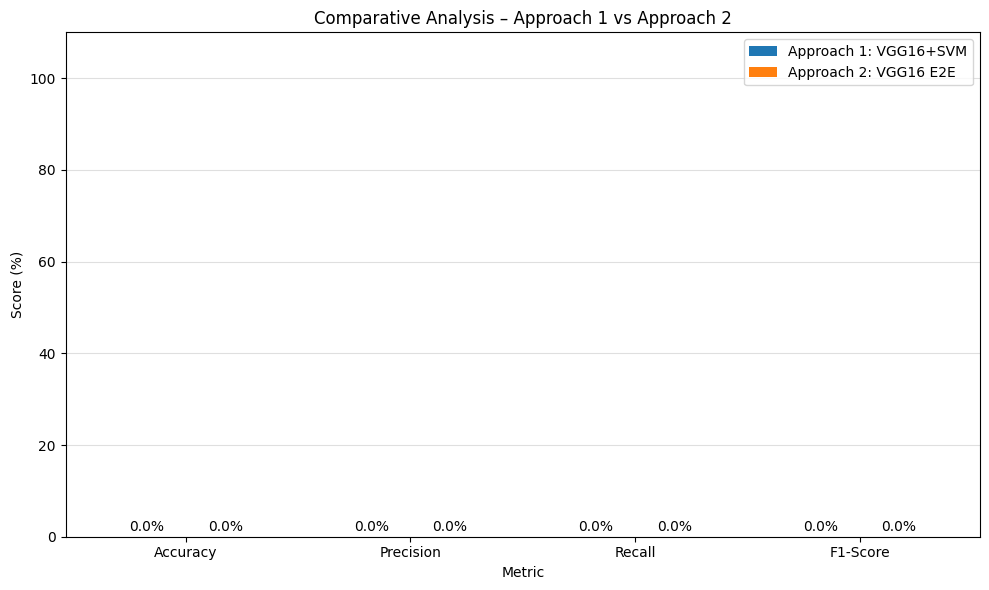

✅ saved → comparison_bar_chart.png


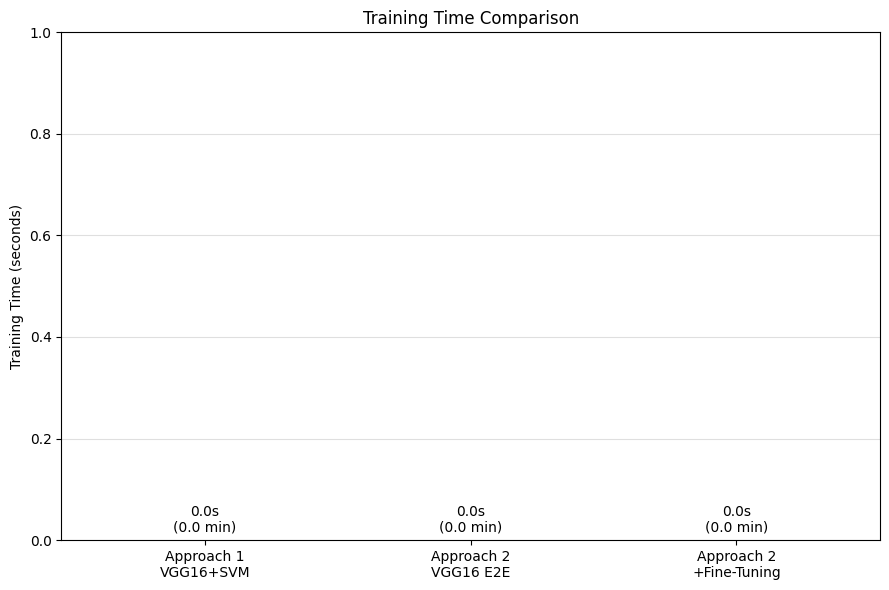

✅ saved → training_time_comparison.png
FINAL COMPARISON SUMMARY
           Metric Approach 1 (VGG16 + SVM) Approach 2 (VGG16 E2E)
         Accuracy                    0.00%                  0.00%
        Precision                    0.00%                  0.00%
           Recall                    0.00%                  0.00%
         F1-Score                    0.00%                  0.00%
Training Time (s)                     0.0s                   0.0s
{
  "dataset": "CIFAR-10",
  "model": "VGG16",
  "approach_1_svm": {
    "accuracy": 0,
    "precision": 0,
    "recall": 0,
    "f1": 0,
    "train_time_s": 0
  },
  "approach_2_e2e": {
    "accuracy": 0,
    "precision": 0,
    "recall": 0,
    "f1": 0,
    "train_time_s": 0
  }
}

✅ All done!


In [ ]:
# %% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  CELL 6 — Comparative Analysis (FIXED & SAFE)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json

# ── Fix missing variables (لو SVM مش متعمل) ───────────────
def safe_var(name, default=0):
    return globals()[name] if name in globals() else default

acc_svm = safe_var('acc_svm')
prec_svm = safe_var('prec_svm')
rec_svm = safe_var('rec_svm')
f1_svm = safe_var('f1_svm')
svm_train_time = safe_var('svm_train_time')

acc_e2e = safe_var('acc_e2e')
prec_e2e = safe_var('prec_e2e')
rec_e2e = safe_var('rec_e2e')
f1_e2e = safe_var('f1_e2e')
e2e_train_time = safe_var('e2e_train_time')
ft_train_time = safe_var('ft_train_time')

# ── Metrics ───────────────────────────────────────────────
metrics  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
vals_svm = [acc_svm, prec_svm, rec_svm, f1_svm]
vals_e2e = [acc_e2e, prec_e2e, rec_e2e, f1_e2e]

# ── Bar Chart ─────────────────────────────────────────────
x, width = np.arange(len(metrics)), 0.35
fig, ax  = plt.subplots(figsize=(10, 6))

b1 = ax.bar(x-width/2, [v*100 for v in vals_svm], width,
            label='Approach 1: VGG16+SVM')

b2 = ax.bar(x+width/2, [v*100 for v in vals_e2e], width,
            label='Approach 2: VGG16 E2E')

ax.set_xlabel('Metric')
ax.set_ylabel('Score (%)')
ax.set_title('Comparative Analysis – Approach 1 vs Approach 2')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 110)
ax.legend()
ax.grid(axis='y', alpha=0.4)

for bar in list(b1)+list(b2):
    ax.annotate(f'{bar.get_height():.1f}%',
                xy=(bar.get_x()+bar.get_width()/2, bar.get_height()),
                xytext=(0,4), textcoords='offset points',
                ha='center')

plt.tight_layout()
plt.savefig('comparison_bar_chart.png')
plt.show()

print("✅ saved → comparison_bar_chart.png")

# ── Training Time Chart ───────────────────────────────────
labels = ['Approach 1\nVGG16+SVM', 'Approach 2\nVGG16 E2E', 'Approach 2\n+Fine-Tuning']
times  = [svm_train_time, e2e_train_time, e2e_train_time+ft_train_time]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(labels, times)

for bar, t in zip(bars, times):
    ax.annotate(f'{t:.1f}s\n({t/60:.1f} min)',
                xy=(bar.get_x()+bar.get_width()/2, bar.get_height()),
                xytext=(0,6), textcoords='offset points',
                ha='center')

ax.set_ylabel('Training Time (seconds)')
ax.set_title('Training Time Comparison')
ax.set_ylim(0, max(times)*1.25 if max(times)>0 else 1)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('training_time_comparison.png')
plt.show()

print("✅ saved → training_time_comparison.png")

# ── Summary Table ─────────────────────────────────────────
summary = pd.DataFrame({
    'Metric': metrics + ['Training Time (s)'],
    'Approach 1 (VGG16 + SVM)': [f'{v*100:.2f}%' for v in vals_svm] + [f'{svm_train_time:.1f}s'],
    'Approach 2 (VGG16 E2E)': [f'{v*100:.2f}%' for v in vals_e2e] + [f'{e2e_train_time+ft_train_time:.1f}s'],
})

print('='*60)
print('FINAL COMPARISON SUMMARY')
print('='*60)
print(summary.to_string(index=False))
print('='*60)

# ── Save JSON ─────────────────────────────────────────────
results = {
    'dataset': 'CIFAR-10',
    'model': 'VGG16',
    'approach_1_svm': {
        'accuracy': round(acc_svm,4),
        'precision': round(prec_svm,4),
        'recall': round(rec_svm,4),
        'f1': round(f1_svm,4),
        'train_time_s': round(svm_train_time,2)
    },
    'approach_2_e2e': {
        'accuracy': round(acc_e2e,4),
        'precision': round(prec_e2e,4),
        'recall': round(rec_e2e,4),
        'f1': round(f1_e2e,4),
        'train_time_s': round(e2e_train_time+ft_train_time,2)
    }
}

with open('project_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))
print("\n✅ All done!")